# Ito (2022) full-depth sampling maps

Alternate notebook producer for `Figures/GFDL_ESM4_Ito2022_sampling_sensitivity_full_depth_maps.pdf`.


In [1]:
from pathlib import Path
import string
import textwrap
import netCDF4 as nc
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from cartopy import crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point

WORK = Path('/scratch/gpfs/LRGROUP/db9274/GFDL_ESM4_artificial_subsampling')
FULL = Path('/scratch/gpfs/LRGROUP/db9274/Variability_trends_EC/Paper_figures/NETCDF/Fully_sampled_models_annual_o2/o2_1x1bin_GFDL_ESM4_r1i1p1f1.nc')
OI_DIR = WORK / 'workflows/Ito_2022_OI/NETCDF/processed'
OUT = Path('Figures/GFDL_ESM4_Ito2022_sampling_sensitivity_full_depth_maps.pdf')
MAP_DIR = WORK / 'trend_comparison_outputs/fully_minus_gap_filled_trend_maps'
ORIGINAL_MAP = MAP_DIR / 'ito2022_original_4x_4xeast_8x.nc'
PCT30_MAP = MAP_DIR / 'ito2022_fully_minus_gap_filled_level_first_volume_weighted_1967_2019.nc'
RANDOM_MAP = Path('/scratch/gpfs/LRGROUP/db9274/Variability_trends_EC/Paper_figures/cache_gfdl_esm4_randobs_trend_error_maps.nc')
RF_DIR = WORK / 'workflows/Ito_2024_NN/NETCDF/Artificial_subsampling_RF'
REGIONS = ('tropical', 'extratropical', 'southern_ocean')

def edges(z):
    z = np.asarray(z, float); e = np.empty(z.size + 1)
    e[1:-1] = (z[:-1] + z[1:]) / 2; e[0] = max(0, z[0] - (z[1]-z[0])/2); e[-1] = z[-1] + (z[-1]-z[-2])/2
    return e

def years(ds):
    t = ds.variables['time']; return np.array([d.year for d in nc.num2date(t[:], t.units, calendar=getattr(t, 'calendar', 'standard'))])

def trend(path, start=1967, end=2019):
    with nc.Dataset(path) as ds:
        zname = 'lev' if 'lev' in ds.variables else 'depth'; yname = 'y' if 'y' in ds.variables else 'lat'; xname = 'x' if 'x' in ds.variables else 'lon'
        z, lat, lon = [np.asarray(ds.variables[n][:], float) for n in (zname, yname, xname)]; lon = np.mod(lon, 360)
        v = ds.variables['o2']; ta = v.dimensions.index('time'); rem = [d for d in v.dimensions if d != 'time']; order = [rem.index(n) for n in (zname, yname, xname)]
        shape = (z.size, lat.size, lon.size); yy = years(ds)
        wanted_indices = np.array([np.flatnonzero(yy == year)[0] for year in range(start, end + 1)])
        # The objective-mapping products store time last. Reading one longitude
        # slab at a time is orders of magnitude faster than 53 strided global reads.
        if v.dimensions == (xname, yname, zname, 'time'):
            out = np.full(shape, np.nan)
            xyears = np.arange(start, end + 1, dtype=float); xc = xyears - xyears.mean(); denom = np.sum(xc * xc)
            for i in range(0, lon.size, 90):
                j = min(i + 90, lon.size)
                a = np.ma.filled(v[i:j, :, :, wanted_indices], np.nan).astype(float)
                a[a > 1e19] = np.nan
                a = np.transpose(a, (2, 1, 0, 3))
                ok = np.isfinite(a).all(axis=3)
                slope = np.sum(a * xc[None, None, None, :], axis=3) / denom * 10
                out[:, :, i:j] = np.where(ok, slope, np.nan)
                print(f'  {path.name}: longitudes {i + 1}-{j}', flush=True)
            return z, lat, lon, out
        n = np.zeros(shape); sx = np.zeros(shape); sy = np.zeros(shape); sxx = np.zeros(shape); sxy = np.zeros(shape)
        for year in range(start, end + 1):
            total = np.zeros(shape); count = np.zeros(shape, dtype=np.uint8)
            for ti in np.flatnonzero(yy == year):
                ind = [slice(None)] * v.ndim; ind[ta] = int(ti); a = np.ma.filled(v[tuple(ind)], np.nan).astype(float); a[a > 1e19] = np.nan; a = np.transpose(a, order); ok = np.isfinite(a); total += np.where(ok, a, 0); count += ok
            a = np.divide(total, count, out=np.full(shape, np.nan), where=count > 0); ok = np.isfinite(a); n += ok; sx += np.where(ok, year, 0); sy += np.where(ok, a, 0); sxx += np.where(ok, year*year, 0); sxy += np.where(ok, year*a, 0)
    den = n*sxx - sx*sx
    return z, lat, lon, np.divide(n*sxy-sx*sy, den, out=np.full(shape, np.nan), where=(n == end-start+1) & (den != 0))*10

def volume_mean(a, z):
    dz = np.diff(edges(z))[:, None, None]; ok = np.isfinite(a); num = np.nansum(np.where(ok, a*dz, np.nan), axis=0); den = np.sum(np.where(ok, dz, 0), axis=0)
    return np.divide(num, den, out=np.full(num.shape, np.nan), where=den > 0)

def band_volumes():
    with nc.Dataset(FULL) as ds:
        z = np.asarray(ds.variables['lev'][:], float); v = ds.variables['o2']; a = np.ma.filled(v[0], np.nan)
    e = edges(z); dz1 = np.maximum(np.minimum(e[1:], 2000)-e[:-1], 0); dz2 = np.maximum(e[1:]-np.maximum(e[:-1], 2000), 0); ok = np.isfinite(a)
    return np.sum(np.where(ok, dz1[:,None,None], 0), axis=0), np.sum(np.where(ok, dz2[:,None,None], 0), axis=0)

def from_bands(ds, prefix, upper_v, lower_v):
    a=np.asarray(ds[f'{prefix}_upper_2000m'],float); b=np.asarray(ds[f'{prefix}_below_2000m'],float); oka=np.isfinite(a)&(upper_v>0); okb=np.isfinite(b)&(lower_v>0); num=np.where(oka,a*upper_v,0)+np.where(okb,b*lower_v,0); den=np.where(oka,upper_v,0)+np.where(okb,lower_v,0)
    return np.divide(num,den,out=np.full(num.shape,np.nan),where=den>0)

def regional_error_maps(method):
    """Return mapped-minus-full depth-mean trends for the 2,000-profile cases."""
    if method == 'oi':
        start, end = 1967, 2019
        paths = [OI_DIR / f'o2_grid_1x1_GFDL_ESM4_regional_{region}_2000.nc'
                 for region in REGIONS]
    elif method == 'rf':
        start, end = 1965, 2021
        paths = [RF_DIR / f'GFDL_ESM4_regional_{region}_2000_r1i1p1f1_oxygen_gridded_RF.nc'
                 for region in REGIONS]
    else:
        raise ValueError(f'Unknown reconstruction method: {method}')
    cache = Path(f'Figures/GFDL_ESM4_{method}_regional_2000_full_depth_error.npz')
    if cache.exists() and cache.stat().st_mtime >= max(p.stat().st_mtime for p in [FULL, *paths]):
        with np.load(cache) as saved:
            return [saved[region] for region in REGIONS]
    z, lat, lon, full = trend(FULL, start, end)
    full_mean = volume_mean(full, z)
    fields = {}
    for region, path in zip(REGIONS, paths):
        zz, yy, xx, mapped = trend(path, start, end)
        if not (np.allclose(zz, z) and np.allclose(yy, lat) and np.allclose(xx, lon)):
            raise ValueError(f'Coordinate mismatch for {path}')
        fields[region] = volume_mean(mapped, zz) - full_mean
    cache.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(cache, **fields)
    return [fields[region] for region in REGIONS]

def main():
    z, lat, lon, full = trend(FULL)
    upper_v, lower_v = band_volumes()
    with xr.open_dataset(ORIGINAL_MAP) as original, xr.open_dataset(RANDOM_MAP) as random, xr.open_dataset(PCT30_MAP) as pct30:
        fields = [
            -from_bands(original, 'fully_minus_gap_filled_original', upper_v, lower_v),
            -from_bands(random, 'randobs_oi', upper_v, lower_v),
            -from_bands(pct30, 'fully_minus_gap_filled_30', upper_v, lower_v),
        ]
    labels = [
        'Historical\ncoverage',
        'Uniform sampling at\nhistorical coverage',
        'Uniform sampling at\n30% coverage',
        '2,000 added profiles:\nTropical Oceans',
        '2,000 added profiles:\nNorth Atlantic +\nNorth Pacific Oceans',
        '2,000 added profiles:\nSouthern Ocean',
    ]
    fields.extend(regional_error_maps('oi'))
    values = np.concatenate([np.abs(x[np.isfinite(x)]) for x in fields if np.isfinite(x).any()])
    lim = float(np.nanpercentile(values, 99))
    if not np.isfinite(lim) or lim <= 0: lim = 1.0
    norm = TwoSlopeNorm(vmin=-lim, vcenter=0, vmax=lim)
    plt.rcParams.update({'font.size': 11, 'pdf.fonttype': 42, 'savefig.dpi': 600, 'savefig.facecolor': 'white'})
    fig, axes = plt.subplots(2, 3, figsize=(10, 6.0), subplot_kw={'projection': ccrs.Robinson(central_longitude=180)}, constrained_layout=True)
    mesh = None
    for i, (ax, field, label) in enumerate(zip(axes.flat, fields, labels)):
        cyc, clon = add_cyclic_point(field, coord=lon); mesh = ax.pcolormesh(clon, lat, cyc, transform=ccrs.PlateCarree(), cmap='bwr', norm=norm, shading='auto', rasterized=True)
        ax.set_global(); ax.add_feature(cfeature.LAND, facecolor='0.85', edgecolor='none', zorder=2); ax.coastlines(linewidth=.45, color='.15', zorder=3); ax.gridlines(linewidth=.25, color='.55', alpha=.4)
        ax.set_title(f'{string.ascii_lowercase[i]}. {label}', fontsize=12, fontweight='bold', pad=7)
    cb = fig.colorbar(mesh, ax=axes, orientation='horizontal', shrink=.62, pad=.08, aspect=35, extend='both'); cb.set_label('|Sampling-and-reconstruction effect| (µmol kg⁻¹ decade⁻¹)', fontsize=11); cb.ax.tick_params(labelsize=11)
    OUT.parent.mkdir(exist_ok=True); fig.savefig(OUT, bbox_inches='tight', pad_inches=.03); print(f'Saved {OUT}'); plt.show(); plt.close(fig)


/scratch/gpfs/GEOCLIM/LRGROUP/db9274/Anaconda/envs/xmip/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


  o2_grid_1x1_GFDL_ESM4_regional_tropical_2000.nc: longitudes 1-90


  o2_grid_1x1_GFDL_ESM4_regional_tropical_2000.nc: longitudes 91-180


  o2_grid_1x1_GFDL_ESM4_regional_tropical_2000.nc: longitudes 181-270


  o2_grid_1x1_GFDL_ESM4_regional_tropical_2000.nc: longitudes 271-360


  o2_grid_1x1_GFDL_ESM4_regional_extratropical_2000.nc: longitudes 1-90


...

  o2_grid_1x1_GFDL_ESM4_regional_southern_ocean_2000.nc: longitudes 1-90


  o2_grid_1x1_GFDL_ESM4_regional_southern_ocean_2000.nc: longitudes 91-180


  o2_grid_1x1_GFDL_ESM4_regional_southern_ocean_2000.nc: longitudes 181-270


  o2_grid_1x1_GFDL_ESM4_regional_southern_ocean_2000.nc: longitudes 271-360


Saved Figures/GFDL_ESM4_Ito2022_sampling_sensitivity_full_depth_maps.pdf


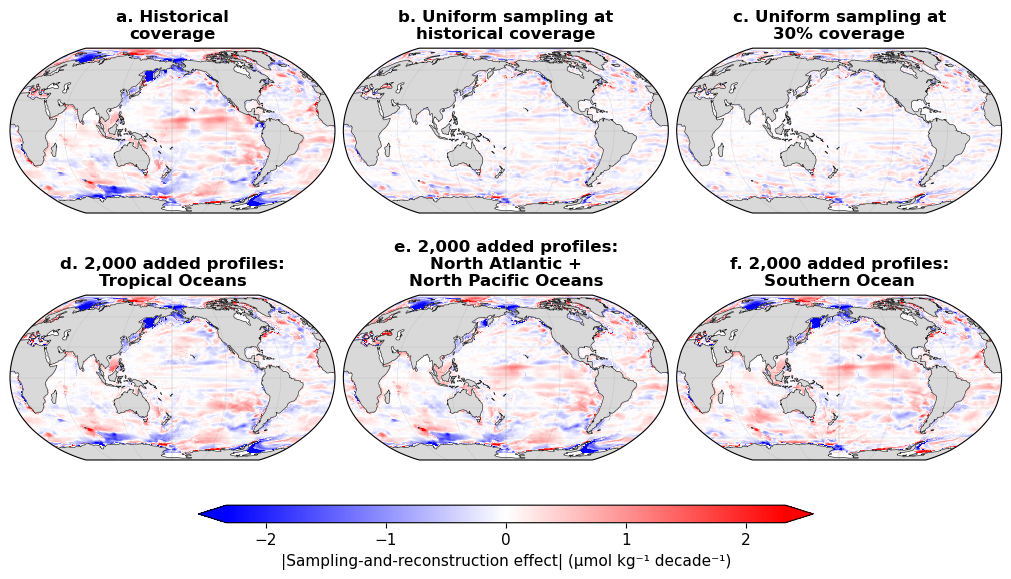

In [2]:
main()
